# d_hidden=8192 + k-annealing SAE on vilip1 (ESM-C layer 23)

Builds on `decodernorm_fix_vilip1_train_eval.ipynb` (plain single-level
TopK + AuxK):

1. **`d_hidden`: 4096 -> 8192.** Not an architecture change -- `d_hidden` was
   already a free constructor arg. Motivated directly by the benchmark data:
   FVE climbed monotonically 512->1024->2048->4096 with the dictionary still
   only 1/4096 dead at the end -- no sign of capacity saturation yet, so
   this tests whether more width keeps buying reconstruction quality.
2. **k-annealing during training** (Gao et al. 2024, section A.2): start
   training with `k=128` active features per residue and linearly anneal
   down to `k=64` over the first `K_ANNEAL_FRAC` (10%) of training steps,
   instead of fixing k=64 from step 0 (what every previous run here did).
   Lets the model find good feature directions under a looser sparsity
   constraint before it hardens. Implemented by mutating `model.k` between
   training steps -- no change to the `SparseAutoencoder` class itself.
   **Validation and the final checkpoint always use k=64** (the annealed
   schedule is train-time only), so held-out FVE stays comparable to every
   prior run and to Biohub's own k=64 convention.

Everything else -- data loading/centering/scaling convention, layer 23,
`auxk=256`, `dead_tokens_threshold=400000`, `batch_size=4096`, `epochs=50`,
`lr=4e-4`, warmup/grad-clip/val-fraction/seed, the decoder-norm `dim=1` fix,
and the Biohub-comparison benchmark methodology -- is reused unchanged.

**Assumes** the `igemmodel-main` folder (same layout as in `Downloads/`) has
been copied into Google Drive. Edit `BASE` in the paths cell below if it
isn't at `MyDrive/igemmodel-main`.

**Outputs** go into the *same* `vilip1_layer23_sae_outputs/` folder under
new `dhidden8192_kanneal_run1` / `dhidden8192_kanneal_*` names -- the
baseline `run1`, `decodernorm_fix_run1`, and `matryoshka_run1` outputs are
never touched.

Needs a GPU runtime (T4 is enough for training; the benchmark cell needs
enough GPU headroom for the real ESM-C-300M forward pass too).

## Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# IMPORTANT: plain `pip install esm` grabs an unrelated PyPI package named
# `esm` -- NOT Biohub's fork. Per Biohub's own model card, their real `esm`
# (the one that registers `esmc` into transformers' architecture registry)
# has to come from GitHub directly; a PyPI release wasn't out yet as of
# their docs. Installing the wrong `esm` is exactly what causes
# `transformers.models.esmc` to not exist / KeyError: 'esmc' later.
!pip install -q -U huggingface_hub safetensors transformers
!pip install -q -U "esm@git+https://github.com/Biohub/esm.git@main"

import esm
print(esm.__file__)  # should point at a fresh git checkout, not dist-packages' old copy
import transformers.models.esmc  # noqa: F401 -- sanity check; raises here (not later) if the install didn't take
print("transformers.models.esmc imported OK")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
/usr/local/lib/python3.12/dist-packages/esm/__init__.py
transformers.models.esmc imported OK


If `biohub/ESMC-300M` or `biohub/ESMC-300M-sae-k64-codebook16384` are gated/rate-limited,
uncomment and run the login cell below (needs a Hugging Face token).

In [ ]:
from huggingface_hub import login
# login()  # uncomment + run if the benchmark cell fails on model download / auth

In [ ]:
from pathlib import Path

# EDIT THIS if you placed igemmodel-main somewhere else in your Drive.
BASE = Path("/content/drive/MyDrive/igemmodel-main/sae/sae_vilip1_dataset")

DATA_DIR = BASE / "vilip1_layer23_65k_per_residue"
OUTPUTS_DIR = BASE / "vilip1_layer23_sae_outputs"

# Self-extract the new data zip if DATA_DIR isn't already populated -- safe
# to re-run (skips if index.csv is already there). Handles either zip
# layout: files directly at the archive root, or nested one level deep
# inside a single top-level folder.
if not (DATA_DIR / "index.csv").exists():
    import shutil
    import zipfile

    zip_path = BASE / "vilip1_layer23_65k_per_residue.zip"
    assert zip_path.exists(), f"Neither {DATA_DIR} nor {zip_path} exist -- check BASE / the zip filename"
    print(f"Unzipping {zip_path} ...")
    staging = DATA_DIR.parent / f"_unzip_staging_{DATA_DIR.name}"
    if staging.exists():
        shutil.rmtree(staging)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(staging)

    if (staging / "index.csv").exists():
        source_dir = staging
    else:
        # Skip macOS Finder-zip junk (__MACOSX metadata folder, .DS_Store, etc.)
        subdirs = [
            p for p in staging.iterdir()
            if p.is_dir() and not p.name.startswith(("__MACOSX", "."))
        ]
        assert len(subdirs) == 1, f"Unexpected zip layout in {staging}: {list(staging.iterdir())}"
        source_dir = subdirs[0]

    DATA_DIR.mkdir(parents=True, exist_ok=True)
    for item in source_dir.iterdir():
        shutil.move(str(item), str(DATA_DIR / item.name))
    shutil.rmtree(staging)
    print(f"Unzipped into {DATA_DIR}")
else:
    print(f"{DATA_DIR} already populated, skipping unzip")

# New run -- does not touch run1 / decodernorm_fix_run1 / matryoshka_run1 or
# their benchmark_results / analysis outputs.
CKPT_DIR = OUTPUTS_DIR / "checkpoints" / "dhidden16384_kanneal_run1"
BENCHMARK_DIR = OUTPUTS_DIR / "benchmark_results"
ANALYSIS_DIR = OUTPUTS_DIR / "analysis"
for d in (CKPT_DIR, BENCHMARK_DIR, ANALYSIS_DIR):
    d.mkdir(parents=True, exist_ok=True)

assert (DATA_DIR / "activations.npy").exists(), f"activations.npy not found in {DATA_DIR} -- check BASE"
assert (DATA_DIR / "index.csv").exists()
assert (DATA_DIR / "manifest_combined.csv").exists()
print("Data dir:", DATA_DIR)
print("Outputs dir:", OUTPUTS_DIR)
print("This run's checkpoints ->", CKPT_DIR)

/content/drive/MyDrive/igemmodel-main/sae/sae_vilip1_dataset/vilip1_layer23_65k_per_residue already populated, skipping unzip
Data dir: /content/drive/MyDrive/igemmodel-main/sae/sae_vilip1_dataset/vilip1_layer23_65k_per_residue
Outputs dir: /content/drive/MyDrive/igemmodel-main/sae/sae_vilip1_dataset/vilip1_layer23_sae_outputs
This run's checkpoints -> /content/drive/MyDrive/igemmodel-main/sae/sae_vilip1_dataset/vilip1_layer23_sae_outputs/checkpoints/dhidden16384_kanneal_run1


## Data loading (verbatim from `sae/training/data.py`, unchanged)

In [ ]:
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import torch


@dataclass
class SAEDataset:
    train_x: torch.Tensor  # (n_train, d_model) float16, RAW (uncentered, unscaled)
    val_x: torch.Tensor  # (n_val, d_model) float16, RAW
    train_source: np.ndarray  # (n_train,) str, row-aligned with train_x
    val_source: np.ndarray  # (n_val,) str, row-aligned with val_x
    mean: torch.Tensor  # (d_model,) float32, computed from train_x only
    scale: float  # computed from train_x only
    train_protein_ids: np.ndarray
    val_protein_ids: np.ndarray


def _stratified_protein_split(design_df, val_fraction, seed):
    """Returns (train_ids, val_ids) sets of protein ids, split independently
    within each `source` group so both splits keep the same source mix."""
    rng = np.random.RandomState(seed)
    train_ids, val_ids = set(), set()
    for source in sorted(design_df["source"].unique()):
        ids = design_df.loc[design_df["source"] == source, "id"].to_numpy()
        perm = rng.permutation(len(ids))
        shuffled = ids[perm]
        n_val = int(round(len(ids) * val_fraction))
        val_ids.update(shuffled[:n_val].tolist())
        train_ids.update(shuffled[n_val:].tolist())
    return train_ids, val_ids


def _expand_to_residue_indices(rows):
    """rows: dataframe with start/length/source columns, one row per protein.
    Returns (residue_indices, residue_source)."""
    idx_parts = []
    source_parts = []
    for start, length, source in zip(rows["start"], rows["length"], rows["source"]):
        idx_parts.append(np.arange(start, start + length))
        source_parts.append(np.full(length, source, dtype=object))
    return np.concatenate(idx_parts), np.concatenate(source_parts)


def load_dataset(data_dir, val_fraction=0.1, seed=0):
    data_dir = Path(data_dir)
    index_df = pd.read_csv(data_dir / "index.csv")
    manifest_df = pd.read_csv(data_dir / "manifest_combined.csv")[["id", "source"]]

    merged = index_df.merge(manifest_df, on="id", how="left")
    assert merged["source"].notna().all(), "some index.csv ids missing from manifest_combined.csv"

    NATURAL_SOURCES = {"natural_binders", "binder_dataset_vilip1"}
    design_df = merged[~merged["source"].isin(NATURAL_SOURCES)].reset_index(drop=True)
    print(
        f"{len(design_df)}/{len(merged)} proteins are designs (excluding "
        f"{len(merged) - len(design_df)} natural/real binders, held out for eval only)"
    )



    train_ids, val_ids = _stratified_protein_split(design_df, val_fraction, seed)
    train_rows = design_df[design_df["id"].isin(train_ids)]
    val_rows = design_df[design_df["id"].isin(val_ids)]
    assert set(train_rows["id"]).isdisjoint(set(val_rows["id"]))

    train_idx, train_source = _expand_to_residue_indices(train_rows)
    val_idx, val_source = _expand_to_residue_indices(val_rows)

    for name, rows_, idx in [("train", train_rows, train_idx), ("val", val_rows, val_idx)]:
        counts = rows_["source"].value_counts()
        print(f"{name}: {len(rows_)} proteins, {len(idx)} residues -- by source: {counts.to_dict()}")

    acts = np.load(data_dir / "activations.npy")  # full load into RAM, not memmap (~3.7GB total)
    train_x = torch.from_numpy(acts[train_idx].copy())
    val_x = torch.from_numpy(acts[val_idx].copy())
    del acts

    mean = train_x.float().mean(dim=0)
    centered_norms = (train_x.float() - mean).norm(dim=-1)
    scale = float(train_x.shape[1] ** 0.5 / centered_norms.mean().item())
    print(f"train mean norm={mean.norm().item():.4f}, scale={scale:.6f}")

    return SAEDataset(
        train_x=train_x,
        val_x=val_x,
        train_source=train_source,
        val_source=val_source,
        mean=mean,
        scale=scale,
        train_protein_ids=train_rows["id"].to_numpy(),
        val_protein_ids=val_rows["id"].to_numpy(),
    )


def iter_batches(x, batch_size, shuffle=True, generator=None):
    """shuffle=True (training): random order, drops a ragged final batch.
    shuffle=False (validation): original row order preserved, includes a
    final partial batch so every row is covered exactly once."""
    n = x.shape[0]
    if shuffle:
        perm = torch.randperm(n, generator=generator)
        n_full = (n // batch_size) * batch_size
        for i in range(0, n_full, batch_size):
            yield x[perm[i : i + batch_size]]
    else:
        for i in range(0, n, batch_size):
            yield x[i : i + batch_size]


def center_scale(x, mean, scale):
    return (x.float() - mean) * scale


def uncenter_unscale(x_proc, mean, scale):
    return x_proc / scale + mean

## Model -- `sae_model.py`'s `SparseAutoencoder`, identical to `decodernorm_fix_vilip1_train_eval.ipynb` (decoder-norm `dim=1`). `d_hidden` and `k`-annealing are handled entirely outside this class.

In [ ]:
import math
from typing import Optional

import torch
import torch.nn as nn
from torch.nn import functional as F


class SparseAutoencoder(nn.Module):
    def __init__(
        self,
        d_model: int,
        d_hidden: int,
        k: int = 64,
        auxk: int = 256,
        dead_tokens_threshold: int = 400_000,
    ):
        super().__init__()

        self.w_enc = nn.Parameter(torch.empty(d_model, d_hidden))
        self.w_dec = nn.Parameter(torch.empty(d_hidden, d_model))
        self.b_enc = nn.Parameter(torch.zeros(d_hidden))
        self.b_dec = nn.Parameter(torch.zeros(d_model))

        self.d_model = d_model
        self.d_hidden = d_hidden
        self.k = k  # mutated directly during training for the k-annealing schedule
        self.auxk = auxk
        self.dead_tokens_threshold = dead_tokens_threshold

        nn.init.kaiming_uniform_(self.w_enc, a=math.sqrt(5))
        self.w_dec.data = self.w_enc.data.T.clone()
        self.w_dec.data /= self.w_dec.data.norm(dim=1, keepdim=True)

        # For each hidden dim, how many residues have been processed since it
        # last fired. Reset to 0 whenever a batch contains a nonzero
        # activation for that feature; incremented by batch size otherwise.
        self.register_buffer("tokens_since_fired", torch.zeros(d_hidden, dtype=torch.long))

    def topk_activation(self, x: torch.Tensor, k: int) -> torch.Tensor:
        """Per-token TopK: keep the k largest (ReLU'd) activations in the last
        dim, zero out the rest. x: (..., d_hidden)."""
        topk = torch.topk(x, k=k, dim=-1, sorted=False)
        values = F.relu(topk.values)
        result = torch.zeros_like(x)
        result.scatter_(-1, topk.indices, values)
        return result

    def dead_feature_mask(self) -> torch.Tensor:
        return self.tokens_since_fired > self.dead_tokens_threshold

    def forward(self, x: torch.Tensor):
        """x: (B, d_model) already centered+scaled. Returns (recon, auxk_recon
        or None, num_dead, latents). Uses self.k, which the training loop
        mutates per-step for k-annealing and pins to the final k for eval."""
        pre_acts = x @ self.w_enc + self.b_enc
        latents = self.topk_activation(pre_acts, self.k)

        if self.training:
            # Gated on train/eval mode -- a validation forward pass must not
            # perturb this bookkeeping, or evaluating on held-out data would
            # corrupt the dead-feature signal AuxK relies on during the next
            # training step.
            fired = (latents != 0).any(dim=0)  # (d_hidden,) any residue in this batch fired it
            self.tokens_since_fired[fired] = 0
            self.tokens_since_fired[~fired] += x.shape[0]

        dead_mask = self.dead_feature_mask()
        num_dead = int(dead_mask.sum().item())

        recon = latents @ self.w_dec + self.b_dec

        if num_dead > 0:
            k_aux = min(self.auxk, num_dead)
            auxk_pre = torch.where(dead_mask[None, :], pre_acts, torch.full_like(pre_acts, -torch.inf))
            auxk_latents = self.topk_activation(auxk_pre, k_aux)
            auxk_recon = auxk_latents @ self.w_dec + self.b_dec
        else:
            auxk_recon = None

        return recon, auxk_recon, num_dead, latents

    @torch.no_grad()
    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Sparse codes only (no reconstruction), e.g. for downstream probing."""
        pre_acts = x @ self.w_enc + self.b_enc
        return self.topk_activation(pre_acts, self.k)

    @torch.no_grad()
    def norm_weights(self) -> None:
        """Keep each decoder feature (row) unit-norm -- prevents the trivial
        trick of shrinking codes and growing decoder norm to fake low
        reconstruction loss. Call after each optimizer step."""
        self.w_dec.data /= self.w_dec.data.norm(dim=1, keepdim=True)

    @torch.no_grad()
    def norm_grad(self) -> None:
        """Remove the gradient component parallel to each decoder feature's
        current direction, so norm_weights's renormalization doesn't fight
        the optimizer step. Call after loss.backward(), before optimizer.step()."""
        if self.w_dec.grad is None:
            return
        dot_products = torch.sum(self.w_dec.data * self.w_dec.grad, dim=1, keepdim=True)
        self.w_dec.grad.sub_(self.w_dec.data * dot_products)


def loss_fn(x, recon, auxk_recon=None):
    """MSE reconstruction loss + AuxK auxiliary loss (coefficient 1/32, per
    Gao et al. section A.2 / InterProt's same choice). Unchanged -- no
    Matryoshka nesting here."""
    auxk_coeff = 1.0 / 32.0

    mse_loss = F.mse_loss(recon, x)
    if auxk_recon is not None:
        residual = (x - recon).detach()
        auxk_loss = auxk_coeff * F.mse_loss(auxk_recon, residual).nan_to_num(0)
    else:
        auxk_loss = torch.tensor(0.0, device=x.device)
    return mse_loss, auxk_loss

## Load dataset

In [ ]:
ds = load_dataset(DATA_DIR, val_fraction=0.1, seed=0)
d_model = ds.train_x.shape[1]
print("d_model:", d_model, "train residues:", ds.train_x.shape[0], "val residues:", ds.val_x.shape[0])

65000/65082 proteins are designs (excluding 82 natural/real binders, held out for eval only)
train: 58500 proteins, 6259857 residues -- by source: {'composite_hotspot_20260728': 36000, 'vilip1_full20k': 18000, 'composite_hotspot': 4500}
val: 6500 proteins, 696005 residues -- by source: {'composite_hotspot_20260728': 4000, 'vilip1_full20k': 2000, 'composite_hotspot': 500}
train mean norm=543.7132, scale=0.078095
d_model: 960 train residues: 6259857 val residues: 696005


## Train

Same hyperparameters as the baseline (`auxk=256`, `dead_tokens_threshold=400000`,
`batch_size=4096`, `epochs=50`, `lr=4e-4`, `warmup_frac=0.05`, `grad_clip=1.0`,
`seed=0`), except:
- `D_HIDDEN = 8192` (was 4096)
- `K_START=128 -> K_END=64` linearly annealed over the first `K_ANNEAL_FRAC=0.1`
  (10%) of training steps, then held at `K_END` for the rest of training.
  **Validation always uses `K_END`** so `val_fve` stays comparable across runs.

Checkpoints/log go to `CKPT_DIR` (`dhidden8192_kanneal_run1/`).

In [ ]:
def fve(sq_err_sum: float, sq_x_sum: float) -> float:
    """Fraction of variance explained: 1 - MSE(recon, x) / MSE(0, x), in the
    centered+scaled space -- same convention as train.py."""
    return 1.0 - sq_err_sum / max(sq_x_sum, 1e-12)


@torch.no_grad()
def validate(model, ds, mean, scale, batch_size, device, eval_k):
    """eval_k: forces model.k to the FINAL (post-anneal) k for the duration
    of validation, regardless of whatever the training loop's schedule has
    it set to at this point -- so val_fve is always measured at the same
    sparsity level across every epoch and every run."""
    model.eval()
    saved_k = model.k
    model.k = eval_k
    sources = sorted(set(ds.val_source.tolist()))
    sq_err = {s: 0.0 for s in sources}
    sq_x = {s: 0.0 for s in sources}
    l0_sum = {s: 0.0 for s in sources}
    n_rows = {s: 0 for s in sources}

    cursor = 0
    for batch in iter_batches(ds.val_x, batch_size, shuffle=False):
        batch_source = ds.val_source[cursor : cursor + batch.shape[0]]
        cursor += batch.shape[0]

        x_proc = center_scale(batch.to(device), mean, scale)
        recon, _, _, latents = model(x_proc)
        per_row_sq_err = (x_proc - recon).pow(2).sum(dim=-1)
        per_row_sq_x = x_proc.pow(2).sum(dim=-1)
        per_row_l0 = (latents != 0).sum(dim=-1).float()

        for s in sources:
            mask = torch.from_numpy(batch_source == s).to(device)
            sq_err[s] += per_row_sq_err[mask].sum().item()
            sq_x[s] += per_row_sq_x[mask].sum().item()
            l0_sum[s] += per_row_l0[mask].sum().item()
            n_rows[s] += int(mask.sum().item())

    assert cursor == ds.val_x.shape[0]

    per_source = {
        s: {"fve": fve(sq_err[s], sq_x[s]), "avg_l0": l0_sum[s] / max(n_rows[s], 1)}
        for s in sources
    }
    pooled = {
        "fve": fve(sum(sq_err.values()), sum(sq_x.values())),
        "avg_l0": sum(l0_sum.values()) / max(sum(n_rows.values()), 1),
    }
    num_dead = int(model.dead_feature_mask().sum().item())
    model.train()
    model.k = saved_k
    return pooled, per_source, num_dead

In [ ]:
import csv
import time

D_HIDDEN = 16384  # was 4096 -- FVE hadn't saturated at 4096 (still 1/4096 dead), testing more capacity
AUXK = 256
DEAD_TOKENS_THRESHOLD = 400_000
BATCH_SIZE = 4096
EPOCHS = 50
LR = 4e-4
WARMUP_FRAC = 0.05
GRAD_CLIP = 1.0
VAL_FRACTION = 0.1
SEED = 0
LOG_EVERY = 50

K_START = 128  # k-annealing: Gao et al. section A.2
K_END = 64     # final k -- matches Biohub's k=64 for benchmark comparability
K_ANNEAL_FRAC = 0.1  # anneal over the first 10% of steps, then hold at K_END


def k_at_step(step, anneal_steps):
    if step >= anneal_steps:
        return K_END
    frac = step / anneal_steps
    return int(round(K_START + (K_END - K_START) * frac))


torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type != "cuda":
    print("WARNING: no CUDA device found, falling back to CPU (will be slow)")

mean = ds.mean.to(device)
scale = ds.scale

model = SparseAutoencoder(
    d_model=d_model,
    d_hidden=D_HIDDEN,
    k=K_START,
    auxk=AUXK,
    dead_tokens_threshold=DEAD_TOKENS_THRESHOLD,
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

steps_per_epoch = ds.train_x.shape[0] // BATCH_SIZE
total_steps = steps_per_epoch * EPOCHS
warmup_steps = max(1, int(WARMUP_FRAC * total_steps))
k_anneal_steps = max(1, int(K_ANNEAL_FRAC * total_steps))


def lr_lambda(step):
    return min(1.0, step / warmup_steps)


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

log_path = CKPT_DIR / "training_log.csv"
sorted_sources = sorted(set(ds.val_source.tolist()))
log_fields = (
    ["epoch", "train_mse", "train_auxk_loss", "epoch_end_k", "val_fve_pooled", "val_avg_l0_pooled", "num_dead"]
    + [f"val_fve_{s}" for s in sorted_sources]
    + [f"val_avg_l0_{s}" for s in sorted_sources]
)
with open(log_path, "w", newline="") as f:
    csv.writer(f).writerow(log_fields)

print(
    f"{steps_per_epoch} steps/epoch x {EPOCHS} epochs = {total_steps} total steps "
    f"(warmup: {warmup_steps} steps, k-anneal: {K_START}->{K_END} over {k_anneal_steps} steps)"
)

generator = torch.Generator().manual_seed(SEED)
best_val_fve = float("-inf")
step = 0
for epoch in range(EPOCHS):
    start = time.time()
    model.train()
    epoch_mse, epoch_auxk, n_batches = 0.0, 0.0, 0
    current_k = K_START
    for batch in iter_batches(ds.train_x, BATCH_SIZE, shuffle=True, generator=generator):
        current_k = k_at_step(step, k_anneal_steps)
        model.k = current_k

        x_proc = center_scale(batch.to(device), mean, scale)
        recon, auxk_recon, num_dead, _ = model(x_proc)
        mse_loss, auxk_loss = loss_fn(x_proc, recon, auxk_recon)
        loss = mse_loss + auxk_loss

        optimizer.zero_grad()
        loss.backward()
        model.norm_grad()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        model.norm_weights()
        scheduler.step()

        epoch_mse += mse_loss.item()
        epoch_auxk += auxk_loss.item()
        n_batches += 1
        step += 1
        if step % LOG_EVERY == 0:
            print(
                f"  step {step}/{total_steps}: mse={mse_loss.item():.4f} "
                f"auxk={auxk_loss.item():.4f} k={current_k} num_dead={num_dead} lr={scheduler.get_last_lr()[0]:.2e}"
            )

    train_mse = epoch_mse / max(n_batches, 1)
    train_auxk = epoch_auxk / max(n_batches, 1)
    pooled, per_source, num_dead = validate(model, ds, mean, scale, BATCH_SIZE, device, eval_k=K_END)
    elapsed = time.time() - start

    per_source_str = ", ".join(f"{s}: fve={m['fve']:.4f} l0={m['avg_l0']:.1f}" for s, m in per_source.items())
    print(
        f"epoch {epoch}: train_mse={train_mse:.4f} train_auxk={train_auxk:.4f} epoch_end_k={current_k} "
        f"val_fve={pooled['fve']:.4f} val_l0={pooled['avg_l0']:.1f} num_dead={num_dead} "
        f"({elapsed:.1f}s) -- {per_source_str}"
    )

    with open(log_path, "a", newline="") as f:
        row = [epoch, train_mse, train_auxk, current_k, pooled["fve"], pooled["avg_l0"], num_dead]
        row += [per_source[s]["fve"] for s in sorted_sources]
        row += [per_source[s]["avg_l0"] for s in sorted_sources]
        csv.writer(f).writerow(row)

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "config": {
            "d_model": d_model,
            "d_hidden": D_HIDDEN,
            "k": K_END,  # deployed/eval k -- matches Biohub's k=64 convention
            "auxk": AUXK,
            "dead_tokens_threshold": DEAD_TOKENS_THRESHOLD,
        },
        "mean": ds.mean,
        "scale": scale,
        "train_protein_ids": ds.train_protein_ids,
        "val_protein_ids": ds.val_protein_ids,
        "hyperparameters": {
            "batch_size": BATCH_SIZE, "epochs": EPOCHS, "lr": LR, "warmup_frac": WARMUP_FRAC,
            "grad_clip": GRAD_CLIP, "val_fraction": VAL_FRACTION, "seed": SEED,
            "k_start": K_START, "k_end": K_END, "k_anneal_frac": K_ANNEAL_FRAC,
        },
        "epoch": epoch,
        "val_fve": pooled["fve"],
    }
    torch.save(checkpoint, CKPT_DIR / "latest.pt")
    if pooled["fve"] > best_val_fve:
        best_val_fve = pooled["fve"]
        torch.save(checkpoint, CKPT_DIR / "best.pt")
        print(f"  new best val_fve={best_val_fve:.4f}, saved best.pt")

print(f"Done. Best val_fve={best_val_fve:.4f}. Checkpoints in {CKPT_DIR}")

Device: cuda
1528 steps/epoch x 50 epochs = 76400 total steps (warmup: 3820 steps, k-anneal: 128->64 over 7640 steps)
  step 50/76400: mse=0.8812 auxk=0.0000 k=128 num_dead=0 lr=5.24e-06
  step 100/76400: mse=0.7124 auxk=0.0000 k=127 num_dead=0 lr=1.05e-05
  step 150/76400: mse=0.5429 auxk=0.0169 k=127 num_dead=9 lr=1.57e-05
  step 200/76400: mse=0.3812 auxk=0.0110 k=126 num_dead=457 lr=2.09e-05
  step 250/76400: mse=0.2833 auxk=0.0080 k=126 num_dead=2248 lr=2.62e-05
  step 300/76400: mse=0.2385 auxk=0.0082 k=125 num_dead=3993 lr=3.14e-05
  step 350/76400: mse=0.2073 auxk=0.0072 k=125 num_dead=4503 lr=3.66e-05
  step 400/76400: mse=0.1844 auxk=0.0058 k=125 num_dead=4644 lr=4.19e-05
  step 450/76400: mse=0.1700 auxk=0.0050 k=124 num_dead=4645 lr=4.71e-05
  step 500/76400: mse=0.1550 auxk=0.0044 k=124 num_dead=4663 lr=5.24e-05
  step 550/76400: mse=0.1441 auxk=0.0039 k=123 num_dead=4688 lr=5.76e-05
  step 600/76400: mse=0.1367 auxk=0.0036 k=123 num_dead=4642 lr=6.28e-05
  step 650/76400:

## Training curves

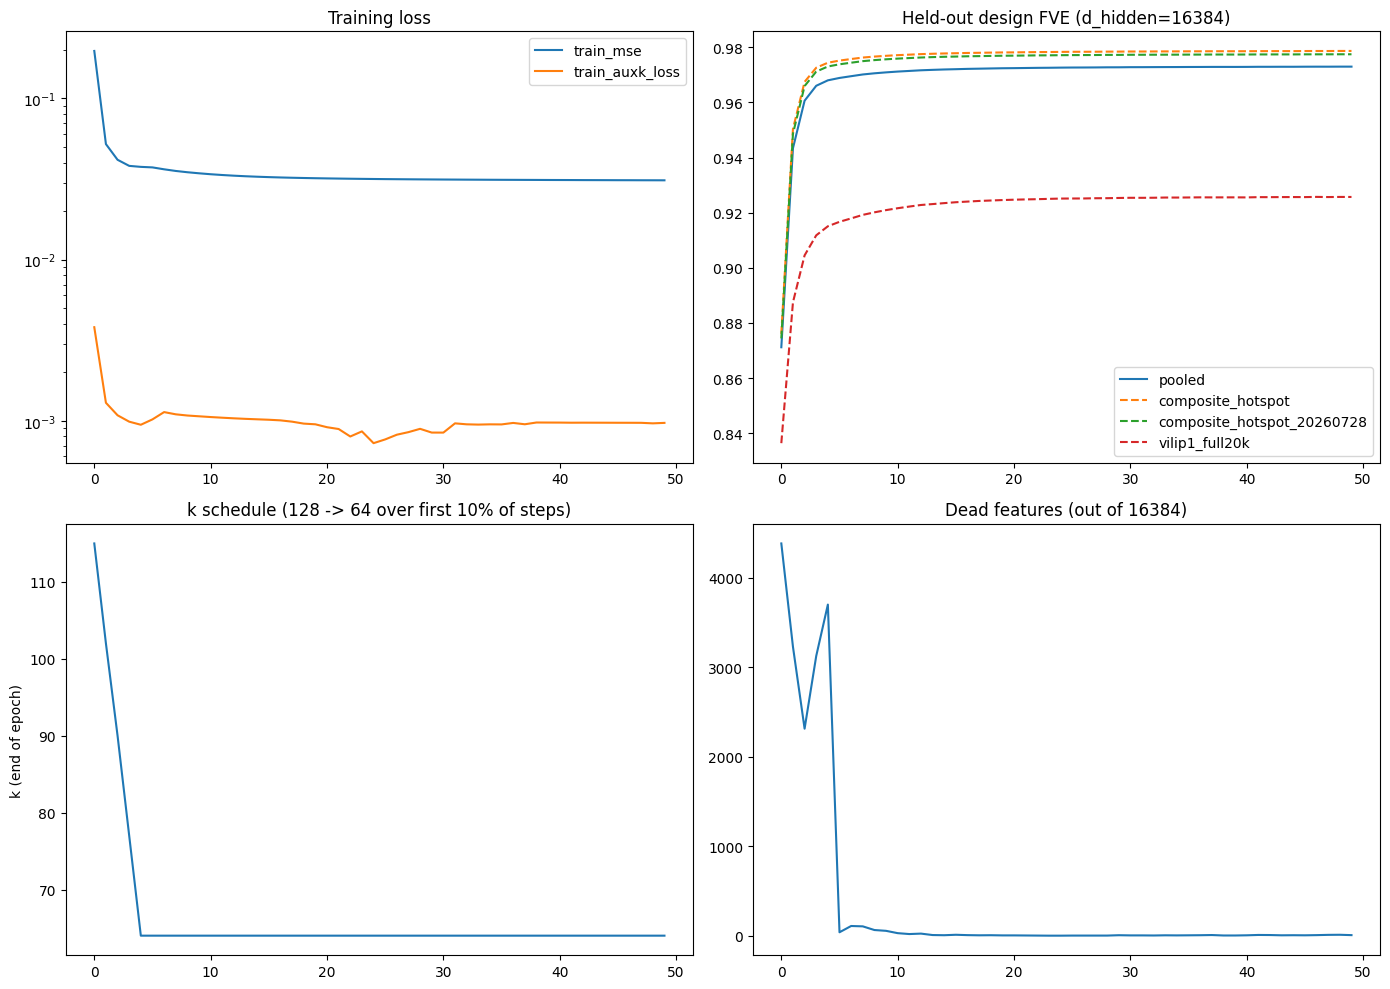

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

log_df = pd.read_csv(log_path)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(log_df["epoch"], log_df["train_mse"], label="train_mse")
axes[0, 0].plot(log_df["epoch"], log_df["train_auxk_loss"], label="train_auxk_loss")
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("Training loss")
axes[0, 0].legend()

axes[0, 1].plot(log_df["epoch"], log_df["val_fve_pooled"], label="pooled")
for s in sorted_sources:
    axes[0, 1].plot(log_df["epoch"], log_df[f"val_fve_{s}"], label=s, linestyle="--")
axes[0, 1].set_title(f"Held-out design FVE (d_hidden={D_HIDDEN})")
axes[0, 1].legend()

axes[1, 0].plot(log_df["epoch"], log_df["epoch_end_k"])
axes[1, 0].set_title(f"k schedule ({K_START} -> {K_END} over first {K_ANNEAL_FRAC*100:.0f}% of steps)")
axes[1, 0].set_ylabel("k (end of epoch)")

axes[1, 1].plot(log_df["epoch"], log_df["num_dead"])
axes[1, 1].set_title(f"Dead features (out of {D_HIDDEN})")

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "dhidden8192_kanneal_training_curves.png", dpi=150)
plt.show()

## Benchmark vs. Biohub's official general-purpose SAE

Same methodology as `sae/training/benchmark.py` (real ESM-C forward pass +
Biohub's official `add_sae_models` encode hook + their published
`W_dec`/`b_dec` for decode, FVE against a shared baseline). Reports "ours"
(this `d_hidden=8192` + k-annealed model, evaluated at k=64) vs. "biohub"
(their fixed 16384), on both held-out designs and natural binders.

Accumulates running sums per batch rather than concatenating full
per-residue tensors --
necessary here too, since `d_hidden=16384` codes are twice the size of the
4096-wide runs.

Downloads `biohub/ESMC-300M` (~300M params) plus the official SAE weights --
needs a GPU runtime and internet access. If you hit a CUDA OOM from a
previous failed attempt in this same session, restart the runtime first.

In [ ]:
import numpy
import pandas as pd
import torch
from huggingface_hub import hf_hub_download
from safetensors import safe_open
from transformers import AutoModel, AutoTokenizer
from pathlib import Path
CKPT_DIR = Path("/content/drive/MyDrive/igemmodel-main/sae/sae_vilip1_dataset/vilip1_layer23_sae_outputs/checkpoints/dhidden16384_kanneal_run1")
BIOHUB_MODEL = "biohub/ESMC-300M"
BIOHUB_SAE_REPO = "biohub/ESMC-300M-sae-k64-codebook16384"
LAYER = 23
BENCH_BATCH_SIZE = 16


def load_biohub_decoder_weights(layer=LAYER):
    """W_dec/b_dec only -- decode is the one step Biohub's public API doesn't
    expose directly, so we apply their own published weights ourselves."""
    path = hf_hub_download(BIOHUB_SAE_REPO, f"layer_{layer}.safetensors")
    with safe_open(path, framework="pt") as f:
        return f.get_tensor("W_dec"), f.get_tensor("b_dec")


def run_batches(model, tokenizer, sequences, device, batch_size):
    """Yields (seq_index, hidden_layer23, official_sae_codes) per sequence,
    both (L_i, D) with CLS/EOS/padding already excluded."""
    order = sorted(range(len(sequences)), key=lambda i: len(sequences[i]))
    for start in range(0, len(order), batch_size):
        batch_idx = order[start : start + batch_size]
        batch_seqs = [sequences[i] for i in batch_idx]

        inputs = tokenizer(batch_seqs, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.inference_mode():
            output = model(**inputs, output_hidden_states=True)

        hidden = output.hidden_states[LAYER].float()  # (B, L_padded, D)
        official_flat = output["sae_outputs"][f"layer{LAYER}"]
        if official_flat.is_sparse:
            official_flat = official_flat.to_dense()
        official_flat = official_flat.float()  # (total_real_tokens_in_batch, codebook)

        attention_mask = inputs["attention_mask"]
        seq_lens = attention_mask.sum(dim=1)
        cursor = 0
        for i, length in enumerate(seq_lens.tolist()):
            real = slice(1, length - 1)  # exclude CLS (0) and EOS (length-1)
            hidden_i = hidden[i, real]
            official_i = official_flat[cursor : cursor + length][1:-1]
            cursor += length
            assert hidden_i.shape[0] == official_i.shape[0], (
                f"seq {i}: hidden gave {hidden_i.shape[0]} real residues, "
                f"official_flat slice gave {official_i.shape[0]}"
            )
            yield batch_idx[i], hidden_i, official_i


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load best d_hidden=16384 + k-annealed checkpoint (config["k"]=K_END=64).
ckpt = torch.load(CKPT_DIR / "best.pt", map_location=device, weights_only=False)
our_model = SparseAutoencoder(**ckpt["config"]).to(device)
our_model.load_state_dict(ckpt["model_state_dict"])
our_model.eval()
our_mean = ckpt["mean"].to(device)
our_scale = ckpt["scale"]

manifest = pd.read_csv(DATA_DIR / "manifest_combined.csv")
val_ids = set(ckpt["val_protein_ids"].tolist())
val_rows = manifest[manifest["id"].isin(val_ids)]
NATURAL_SOURCES = {"natural_binders", "binder_dataset_vilip1"}
natural_rows = manifest[manifest["source"].isin(NATURAL_SOURCES)]

print(f"Loading {BIOHUB_MODEL} + official SAE hook at layer {LAYER}...")
biohub_model = AutoModel.from_pretrained(BIOHUB_MODEL, device_map="auto", trust_remote_code=True).eval()
tokenizer = AutoTokenizer.from_pretrained(BIOHUB_MODEL, trust_remote_code=True)
sae = AutoModel.from_pretrained(
    BIOHUB_SAE_REPO, allow_patterns=["config.json", f"layer_{LAYER}.safetensors"], device=biohub_model.device,
    trust_remote_code=True,
)
sae.initialize_layers([LAYER])
biohub_model.add_sae_models([sae.layers[str(LAYER)]])
biohub_W_dec, biohub_b_dec = load_biohub_decoder_weights()
biohub_W_dec, biohub_b_dec = biohub_W_dec.to(device), biohub_b_dec.to(device)

MODEL_NAMES = ["ours", "biohub"]
DICT_SIZES = {"ours": ckpt["config"]["d_hidden"], "biohub": 16384}

all_rows = []
for split_name, rows in [("held_out_designs", val_rows), ("natural_binders_qualitative", natural_rows)]:
    sequences = rows["sequence"].tolist()
    sources = rows["source"].tolist()
    ids = rows["id"].tolist()
    print(f"{split_name}: {len(sequences)} sequences")

    split_sources = sorted(set(sources))
    acc = {
        name: {src: {"sq_err": 0.0, "sq_baseline": 0.0, "l0_sum": 0.0, "n": 0} for src in split_sources}
        for name in MODEL_NAMES
    }
    fired_ever = {
        name: {src: torch.zeros(DICT_SIZES[name], dtype=torch.bool, device=device) for src in split_sources}
        for name in MODEL_NAMES
    }

    for seq_i, hidden, official_codes in run_batches(biohub_model, tokenizer, sequences, device, BENCH_BATCH_SIZE):
        src = sources[seq_i]

        x_proc = center_scale(hidden, our_mean, our_scale)
        with torch.no_grad():
            our_recon_proc, _, _, our_codes = our_model(x_proc)
        our_recon = uncenter_unscale(our_recon_proc, our_mean, our_scale)

        # Biohub's real forward() z-score normalizes PER TOKEN before
        # W_enc/W_dec/b_dec and never un-normalizes internally -- recompute
        # the same per-token mean/std from ground-truth `hidden` and invert
        # it ourselves to compare in raw activation-space units.
        token_mean = hidden.mean(dim=-1, keepdim=True)
        token_std = (hidden - token_mean).std(dim=-1, keepdim=True)
        biohub_recon = (official_codes @ biohub_W_dec + biohub_b_dec) * (token_std + 1e-5) + token_mean

        for name, recon, codes in [("ours", our_recon, our_codes), ("biohub", biohub_recon, official_codes)]:
            acc[name][src]["sq_err"] += (hidden - recon).pow(2).sum().item()
            acc[name][src]["sq_baseline"] += (hidden - our_mean).pow(2).sum().item()
            acc[name][src]["l0_sum"] += (codes != 0).sum().item()
            acc[name][src]["n"] += hidden.shape[0]
            fired_ever[name][src] |= (codes != 0).any(dim=0)

        print(f"  {ids[seq_i]} (len={hidden.shape[0]}) processed")

    for name in MODEL_NAMES:
        dict_size = DICT_SIZES[name]
        for src in ["__pooled__"] + split_sources:
            if src == "__pooled__":
                sq_err = sum(acc[name][s]["sq_err"] for s in split_sources)
                sq_baseline = sum(acc[name][s]["sq_baseline"] for s in split_sources)
                l0_sum = sum(acc[name][s]["l0_sum"] for s in split_sources)
                n = sum(acc[name][s]["n"] for s in split_sources)
                fired = torch.zeros(dict_size, dtype=torch.bool, device=device)
                for s in split_sources:
                    fired |= fired_ever[name][s]
            else:
                sq_err = acc[name][src]["sq_err"]
                sq_baseline = acc[name][src]["sq_baseline"]
                l0_sum = acc[name][src]["l0_sum"]
                n = acc[name][src]["n"]
                fired = fired_ever[name][src]
            if n == 0:
                continue
            all_rows.append(
                {
                    "split": split_name,
                    "model": name,
                    "source": src,
                    "n_residues": n,
                    "fve": 1.0 - sq_err / max(sq_baseline, 1e-12),
                    "avg_l0": l0_sum / n,
                    "n_dead": dict_size - int(fired.sum().item()),
                    "dict_size": dict_size,
                }
            )
        pooled_row = [
            r for r in all_rows if r["split"] == split_name and r["model"] == name and r["source"] == "__pooled__"
        ][0]
        print(f"  {name}: fve={pooled_row['fve']:.4f} dead={pooled_row['n_dead']}/{pooled_row['dict_size']}")

out_df = pd.DataFrame(all_rows)
out_df.to_csv(BENCHMARK_DIR / "dhidden8192_kanneal_benchmark_summary.csv", index=False)
print(f"\nWrote {BENCHMARK_DIR / 'dhidden8192_kanneal_benchmark_summary.csv'}")
out_df

Loading biohub/ESMC-300M + official SAE hook at layer 23...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
ESMC: transformer_engine is not installed; falling back to pure-PyTorch LayerNorm+Linear / LayerNorm+MLP. Outputs will differ numerically — measured on the unnormalized residual stream (before the final LayerNorm), ~O(10) max-diff in fp32 and ~O(100) in bf16; after the final LayerNorm these shrink to a few ULP and perplexity stays within rounding noise. Install with `pip install transformer-engine[pytorch]` to enable fused fp32-reduction LayerNorm.
ESMC: neither xformers nor fl

🚨 No checkpoint found for ESMCForSequenceClassification.forward. Please add a `checkpoint` arg to `auto_docstring` or add one in ESMCConfig's docstring
🚨 No checkpoint found for ESMCForTokenClassification.forward. Please add a `checkpoint` arg to `auto_docstring` or add one in ESMCConfig's docstring


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
  pres_VCqYessuKQnB5raxBgV9 (len=75) processed
  pres_lF23viSZGAA9QPeJ9M3s (len=75) processed
  pres_HI0kpwNuWJaA0E5jli55 (len=75) processed
  pres_Ehhs2r4DLRVgKaqhpJfa (len=75) processed
  pres_bru8d33HRvjhap85t5S1 (len=75) processed
  pres_dHJQVdDGxrdBv4vGABne (len=75) processed
  pres_bQ4y0WUOsmk3l4TlR4ug (len=75) processed
  pres_4jx7CKPP1txqPEHa4qZX (len=75) processed
  pres_CALwcDNyF5GCGnMLQcqb (len=75) processed
  pres_9sgZpkvUNhoDWfygUbSe (len=75) processed
  pres_wrsh2qMRDskPt4OID7E8 (len=75) processed
  pres_Q2F6XKFTUxqvTjcgJcQx (len=75) processed
  pres_W1n4xFAbH1sQvvJQAbRR (len=75) processed
  pres_A2MFD4ufSPT6uynEHLW0 (len=75) processed
  pres_yAxAcFfC3WFSuT2vw3RB (len=75) processed
  pres_CQ3QVyWIFrF6uc6v4hCQ (len=75) processed
  pres_hwBJgyORfe8UIz47Bp3j (len=75) processed
  pres_NTzilqyzRlohPxjEl3i1 (len=75) processed
  pres_5NojxfHmF5KGiKHZ2req (len=75) processed
  pres_xZmFNwzMbFFFfJgUwpdm (len=75) processed
  pres_Ya

,split,model,source,n_residues,fve,avg_l0,n_dead,dict_size
0,held_out_designs,ours,__pooled__,696005,0.972998,63.987819,49,16384
1,held_out_designs,ours,composite_hotspot,62922,0.978705,63.985077,1422,16384
2,held_out_designs,ours,composite_hotspot_20260728,501279,0.977492,63.985032,145,16384
3,held_out_designs,ours,vilip1_full20k,131804,0.925649,63.999727,716,16384
4,held_out_designs,biohub,__pooled__,696005,0.680455,64.000000,921,16384
5,held_out_designs,biohub,composite_hotspot,62922,0.667324,64.000000,3997,16384
6,held_out_designs,biohub,composite_hotspot_20260728,501279,0.667304,64.000000,1327,16384
7,held_out_designs,biohub,vilip1_full20k,131804,0.814907,64.000000,3023,16384
8,natural_binders_qualitative,ours,__pooled__,41231,0.415183,64.000000,38,16384
9,natural_binders_qualitative,ours,binder_dataset_vilip1,35869,0.409326,64.000000,60,16384


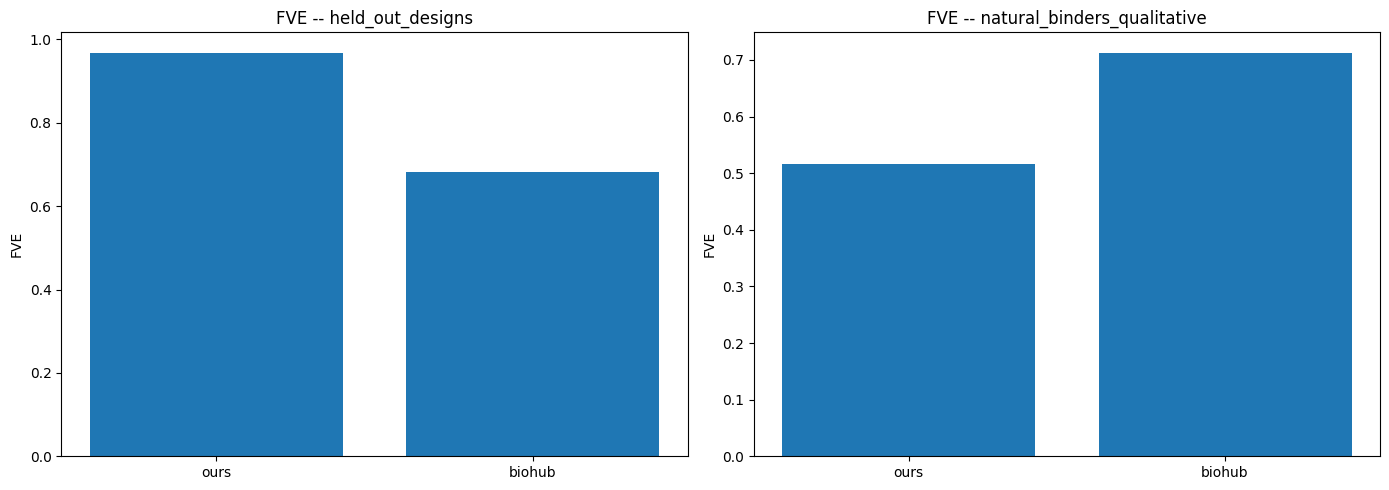

,split,model,source,n_residues,fve,avg_l0,n_dead,dict_size
0,held_out_designs,ours,__pooled__,697746,0.968715,63.993066,24,16384
1,held_out_designs,ours,binder_dataset_vilip1,2621,0.522707,64.000000,3578,16384
2,held_out_designs,ours,composite_hotspot,63347,0.977249,63.991191,1697,16384
3,held_out_designs,ours,composite_hotspot_20260728,500548,0.976764,63.991449,102,16384
4,held_out_designs,ours,vilip1_full20k,131230,0.923797,64.000000,798,16384
5,held_out_designs,biohub,__pooled__,697746,0.680970,64.000000,686,16384
6,held_out_designs,biohub,binder_dataset_vilip1,2621,0.676399,64.000000,7079,16384
7,held_out_designs,biohub,composite_hotspot,63347,0.667381,64.000000,3977,16384
8,held_out_designs,biohub,composite_hotspot_20260728,500548,0.668056,64.000000,1359,16384
9,held_out_designs,biohub,vilip1_full20k,131230,0.813302,64.000000,2952,16384


In [ ]:
import matplotlib.pyplot as plt

pooled_df = out_df[out_df["source"] == "__pooled__"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for split_name, ax in zip(["held_out_designs", "natural_binders_qualitative"], axes):
    sub = pooled_df[pooled_df["split"] == split_name].sort_values("dict_size")
    ax.bar(sub["model"], sub["fve"])
    ax.set_title(f"FVE -- {split_name}")
    ax.set_ylabel("FVE")
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "dhidden8192_kanneal_benchmark_comparison.png", dpi=150)
plt.show()

out_df

## Outputs

- `vilip1_layer23_sae_outputs/checkpoints/dhidden8192_kanneal_run1/{best.pt,latest.pt,training_log.csv}`
- `vilip1_layer23_sae_outputs/benchmark_results/dhidden8192_kanneal_benchmark_summary.csv`
- `vilip1_layer23_sae_outputs/analysis/dhidden8192_kanneal_training_curves.png`,
  `dhidden8192_kanneal_benchmark_comparison.png`

Compare `ours`'s `fve` here against `decodernorm_fix_run1`'s (dim=1 fix
only, d_hidden=4096, no k-annealing, no Matryoshka) to isolate what the
d_hidden increase + k-annealing actually bought you, and against the
original `run1` baseline (0.941 / 0.420) for the full before/after.